# cet-perch Stage 2 — Domain-Adversarial Projection
Frozen Perch V2 backbone + trainable projection trained with GRL.
"Embedding" for UMAP/LODO = projection output, not raw Perch.

## 0. Imports & config

In [2]:
import os, json, logging
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # silences INFO/WARNING from TF C++ backend
os.environ['CUDA_LAUNCH_BLOCKING'] = '0'           # no change in behaviour, just explicit

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score
from sklearn.model_selection import GroupShuffleSplit
from pathlib import Path

tf.get_logger().setLevel('ERROR')                  # silences Python-side TF logging


print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE       = Path('/data2/mromaniuc/cet-det/cet_perchv2')
X_PATH     = BASE / 'X_audio.npy'
META_PATH  = BASE / 'meta_train.parquet'
RUNS_DIR   = BASE / 'runs_stage2'
S1_WEIGHTS = BASE / 'runs/v10_cosine.weights.h5'
RUNS_DIR.mkdir(exist_ok=True)

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED        = 42
BATCH_SIZE  = 32
N_CLASSES   = 10
N_DATASETS  = 11
PROJ_DIM    = 1536
tf.random.set_seed(SEED)
np.random.seed(SEED)

## 1. Load Perch V2 backbone (frozen)

In [5]:
print("Loading Perch V2...")
from perch_hoplite.zoo import model_configs
perch_wrapper = model_configs.load_model_by_name('perch_v2')
raw_model     = perch_wrapper.model
FORWARD_FN    = raw_model.signatures['serving_default']
print(f"  variables: {len(FORWARD_FN.variables)}")

# Smoke test
_dummy = tf.zeros((1, 160000), dtype=tf.float32)
_out   = FORWARD_FN(inputs=_dummy)
print(f"  embedding shape: {_out['embedding'].shape}")

Loading Perch V2...


I0000 00:00:1779345667.104954 2593856 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1779345667.633306 2593856 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


  variables: 497


I0000 00:00:1779345680.654704 2594499 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  embedding shape: (1, 1536)


## 2. Data loading & split

In [6]:
print("Loading data...")
X   = np.load(X_PATH)          # (11769, 160000) float32
meta = pd.read_parquet(META_PATH)
print(f"  X: {X.shape}  meta: {meta.shape}")
print(meta['coarse_class'].value_counts())

# ── Label encoding ────────────────────────────────────────────────────────────
classes  = sorted(meta['coarse_class'].unique())
ds_names = sorted(meta['dataset'].unique())
class2id = {c: i for i, c in enumerate(classes)}
ds2id    = {d: i for i, d in enumerate(ds_names)}
y_class  = meta['coarse_class'].map(class2id).values.astype(np.int32)
y_domain = meta['dataset'].map(ds2id).values.astype(np.int32)

assert len(classes)  == N_CLASSES,  f"Expected {N_CLASSES} classes, got {len(classes)}"
assert len(ds_names) == N_DATASETS, f"Expected {N_DATASETS} datasets, got {len(ds_names)}"

# ── Deterministic split (same as Stage 1) ────────────────────────────────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.175, random_state=SEED)
groups = meta['group_key'].values
train_val_idx, test_idx = next(gss.split(X, y_class, groups=groups))

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.095, random_state=SEED)
train_idx, val_idx = next(gss2.split(
    X[train_val_idx], y_class[train_val_idx],
    groups=groups[train_val_idx]
))
train_idx = train_val_idx[train_idx]
val_idx   = train_val_idx[val_idx]

print(f"  train: {len(train_idx)}  val: {len(val_idx)}  test: {len(test_idx)}")
EPOCH_STEPS = len(train_idx) // BATCH_SIZE
print(f"  EPOCH_STEPS: {EPOCH_STEPS}")

Loading data...
  X: (11769, 160000)  meta: (11769, 15)
coarse_class
background                5043
Delphinus_delphis         1292
Physeter_macrocephalus    1089
Orcinus_orca              1000
Tursiops_truncatus         887
Delphinids                 815
Globicephala_melas         721
Balaenoptera_physalus      539
Grampus_griseus            239
Stenella_coeruleoalba      144
Name: count, dtype: int64
  train: 9125  val: 701  test: 1943
  EPOCH_STEPS: 285


## 3. Balanced dataset with domain labels

In [8]:
def make_dataset(idx, shuffle=True, repeat=True):
    """Returns (audio, {'class_logits': y_c, 'domain_logits': y_d}) batches."""
    x_sub = X[idx].astype(np.float32)
    yc    = y_class[idx]
    yd    = y_domain[idx]

    ds = tf.data.Dataset.from_tensor_slices((x_sub, yc, yd))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(idx), 4096), seed=SEED)
    if repeat:
        ds = ds.repeat()

    # Balanced class sampling
    class_datasets = []
    for c in range(N_CLASSES):
        mask = (yc == c)
        if mask.sum() == 0:
            continue
        c_ds = tf.data.Dataset.from_tensor_slices(
            (x_sub[mask], yc[mask], yd[mask])
        ).shuffle(1024, seed=SEED).repeat()
        class_datasets.append(c_ds)

    if shuffle and repeat:
        ds = tf.data.Dataset.sample_from_datasets(
            class_datasets,
            weights=[1.0 / N_CLASSES] * len(class_datasets),
            seed=SEED
        )

    def pack(audio, yc_, yd_):
        return audio, {'class_logits': yc_, 'domain_logits': yd_}

    ds = ds.batch(BATCH_SIZE).map(pack, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_idx, shuffle=True,  repeat=True)
val_ds   = make_dataset(val_idx,   shuffle=False, repeat=False)
test_ds  = make_dataset(test_idx,  shuffle=False, repeat=False)

## 4. Model: frozen backbone + adversarial projection

In [19]:
@tf.keras.utils.register_keras_serializable()
class GradientReversalLayer(tf.keras.layers.Layer):
    def __init__(self, lambda_value=1.0, **kwargs):
        super().__init__(**kwargs)
        self.lambda_value = float(lambda_value)

    def call(self, x):
        @tf.custom_gradient
        def _reverse(x):
            return x, lambda dy: -self.lambda_value * dy
        return _reverse(x)

    def get_config(self):
        cfg = super().get_config()
        cfg['lambda_value'] = float(self.lambda_value)
        return cfg


class CetPerchStage2(tf.keras.Model):
    """Frozen Perch backbone + trainable domain-adversarial projection."""

    def __init__(self, forward_fn, n_classes=N_CLASSES, n_datasets=N_DATASETS,
                 proj_dim=PROJ_DIM, head_units=256, head_dropout=0.25,
                 lambda_adv=0.0):
        super().__init__()
        self.forward_fn  = forward_fn
        self.lambda_adv  = lambda_adv

        # ── Projection: 1536 → proj_dim (your new embedding space) ───────────
        self.projection = tf.keras.Sequential([
            tf.keras.layers.Dense(proj_dim, use_bias=False,
                                kernel_regularizer=tf.keras.regularizers.l2(1e-3)),  # stronger L2
            tf.keras.layers.LayerNormalization(),
            tf.keras.layers.Dropout(0.3),   # ADD THIS
            tf.keras.layers.Activation('tanh'),
        ], name='projection')

        # ── Species head ──────────────────────────────────────────────────────
        self.class_head = tf.keras.Sequential([
            tf.keras.layers.Dropout(head_dropout),
            tf.keras.layers.Dense(head_units, activation='relu'),
            tf.keras.layers.Dropout(head_dropout),
            tf.keras.layers.Dense(n_classes),
        ], name='class_head')

        # ── Domain head with GRL ──────────────────────────────────────────────
        self.grl = GradientReversalLayer(lambda_value=0.0)
        self.domain_head = tf.keras.Sequential([
            tf.keras.layers.Dense(256, activation='relu'),
            tf.keras.layers.Dropout(head_dropout),
            tf.keras.layers.Dense(n_datasets),
        ], name='domain_head')

    def call(self, audio, training=False):
        # Frozen backbone
        out  = self.forward_fn(inputs=tf.cast(audio, tf.float32))
        emb  = tf.stop_gradient(out['embedding'])   # (batch, 1536)

        # Trainable projection — this becomes your new "embedding"
        proj = self.projection(emb, training=training)   # (batch, proj_dim)

        class_logits  = self.class_head(proj, training=training)
        domain_logits = self.domain_head(self.grl(proj), training=training)

        return {'class_logits': class_logits,
                'domain_logits': domain_logits,
                'embedding': proj}

## 5. MacroF1 callback

In [21]:
class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, val_ds):
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs=None):
        y_true, y_pred = [], []
        for audio, targets in self.val_ds:
            yc  = targets['class_logits']
            out = self.model(audio, training=False)
            y_pred.append(tf.argmax(out['class_logits'], axis=-1).numpy())
            y_true.append(yc.numpy())
        f1 = f1_score(np.concatenate(y_true), np.concatenate(y_pred),
                      average='macro', zero_division=0)
        logs['val_macro_f1'] = float(f1)
        print(f'  val_macro_f1: {f1:.4f}')

## 6. Training helper

In [33]:
def run_variant(variant_name, lambda_adv=0.0, adv_warmup_epochs=3,
                n_epochs=40, initial_lr=3e-4, load_stage1_weights=False, 
                proj_dim=1536):
    print(f"\n{'='*60}")
    print(f"  Variant: {variant_name}  λ_adv={lambda_adv}")
    print(f"  Loading Stage 1 Weights: {load_stage1_weights}")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)

    _fw   = raw_model.signatures['serving_default']
    model = CetPerchStage2(_fw, lambda_adv=lambda_adv, proj_dim=proj_dim)
    _b    = tf.zeros((1, 160000), tf.float32)
    _     = model(_b, training=False)

    # ── Handle Optional Stage 1 Weight Loading ─────────────────────────────
    if load_stage1_weights:
        try:
            s1_head = tf.keras.Sequential([
                tf.keras.layers.Dropout(0.25),
                tf.keras.layers.Dense(256, activation='relu'),
                tf.keras.layers.Dropout(0.25),
                tf.keras.layers.Dense(N_CLASSES),
            ])
            s1_head.build((None, PROJ_DIM))
            s1_head.load_weights(str(S1_WEIGHTS))
            model.class_head.set_weights(s1_head.get_weights())
            print("  Stage 1 class_head weights loaded successfully.")
            del s1_head
        except Exception as e:
            print(f"  Stage 1 weight load skipped/failed: {e}")
            print("  Falling back to training class_head from scratch.")
    else:
        print("  Training model entirely from scratch (Randomly Initialized Class Head & Projection).")

    lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=initial_lr,
        decay_steps=EPOCH_STEPS * n_epochs,
        alpha=1e-7
    )
    optimizer      = tf.keras.optimizers.Adam(lr_schedule)
    class_loss_fn  = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    domain_loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

    best_f1    = 0.0
    best_epoch = 0
    patience   = 12
    wait       = 0
    history    = {
        'train_loss': [], 'train_acc': [],
        'val_loss':   [], 'val_acc':   [], 'val_macro_f1': [],
    }
    weights_path = RUNS_DIR / f'{variant_name}.weights.h5'

    for epoch in range(n_epochs):
        # ── Adversarial lambda schedule ───────────────────────────────────
        if epoch < adv_warmup_epochs:
            lam = 0.0
        else:
            progress = min(1.0, (epoch - adv_warmup_epochs) / 15.0)
            lam = lambda_adv * float(progress)
        
        # This controls the gradient scale being reversed back into the projection layer
        model.grl.lambda_value = float(lam)

        # ── Train ─────────────────────────────────────────────────────────
        train_losses, train_correct, train_total = [], 0, 0
        for step, (audio, targets) in enumerate(train_ds):
            if step >= EPOCH_STEPS:
                break
            yc = targets['class_logits']
            yd = targets['domain_logits']

            # Update all variables (including domain_head) from step 0.
            # During warmup, lam=0, meaning the domain head learns to map domains,
            # but reverses nothing back to scramble the projection layer.
            train_vars = model.trainable_variables

            with tf.GradientTape() as tape:
                out = model(audio, training=True)
                loss_class = class_loss_fn(yc, out['class_logits'])
                
                if lam == 0.0:
                    # Domain head trains on frozen proj — builds strong discriminator
                    proj_sg = tf.stop_gradient(out['embedding'])
                    domain_logits_sg = model.domain_head(proj_sg, training=True)
                    loss_domain = domain_loss_fn(yd, domain_logits_sg)
                    loss_total = loss_class + loss_domain
                else:
                    loss_domain = domain_loss_fn(yd, out['domain_logits'])
                    loss_total = loss_class + loss_domain

            grads = tape.gradient(loss_total, train_vars)
            optimizer.apply_gradients(zip(grads, train_vars))

            train_losses.append(float(loss_class))  # Track classification loss performance
            preds = tf.argmax(out['class_logits'], axis=-1)
            train_correct += int(tf.reduce_sum(tf.cast(preds == tf.cast(yc, tf.int64), tf.int32)).numpy())
            train_total   += int(yc.shape[0])

        history['train_loss'].append(float(np.mean(train_losses)))
        history['train_acc'].append(train_correct / train_total)

        # ── Validate ──────────────────────────────────────────────────────
        val_losses, val_correct, val_total = [], 0, 0
        y_true, y_pred = [], []
        for audio, targets in val_ds:
            yc  = targets['class_logits']
            out = model(audio, training=False)
            loss_val = class_loss_fn(yc, out['class_logits'])
            val_losses.append(float(loss_val))
            preds = tf.argmax(out['class_logits'], axis=-1)
            val_correct += int(tf.reduce_sum(tf.cast(preds == tf.cast(yc, tf.int64), tf.int32)).numpy())
            val_total   += int(yc.shape[0])
            y_pred.append(preds.numpy())
            y_true.append(yc.numpy())

        val_f1 = f1_score(np.concatenate(y_true), np.concatenate(y_pred),
                          average='macro', zero_division=0)
        history['val_loss'].append(float(np.mean(val_losses)))
        history['val_acc'].append(val_correct / val_total)
        history['val_macro_f1'].append(float(val_f1))

        print(f"  epoch {epoch+1:02d}/{n_epochs}"
              f"  loss={history['train_loss'][-1]:.4f}"
              f"  acc={history['train_acc'][-1]:.4f}"
              f"  val_loss={history['val_loss'][-1]:.4f}"
              f"  val_acc={history['val_acc'][-1]:.4f}"
              f"  val_f1={val_f1:.4f}"
              f"  λ={lam:.3f}")

        # ── Checkpoint & early stopping ───────────────────────────────────
        if val_f1 > best_f1:
            best_f1    = val_f1
            best_epoch = epoch + 1
            wait       = 0
            model.save_weights(str(weights_path))
            print(f"    ✓ saved best ({best_f1:.4f})")
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {epoch+1} (patience={patience})")
                break

    print(f"\n  Best val_macro_f1: {best_f1:.4f} @ epoch {best_epoch}")

    # ── Test ──────────────────────────────────────────────────────────────
    model.load_weights(str(weights_path))
    y_true, y_pred = [], []
    for audio, targets in test_ds:
        out = model(audio, training=False)
        y_pred.append(tf.argmax(out['class_logits'], axis=-1).numpy())
        y_true.append(targets['class_logits'].numpy())
    test_f1 = f1_score(np.concatenate(y_true), np.concatenate(y_pred),
                       average='macro', zero_division=0)
    print(f"  Test macro_f1: {test_f1:.4f}")

    cfg = {
        'variant':           variant_name,
        'lambda_adv':        lambda_adv,
        'best_val_macro_f1': best_f1,
        'best_epoch':        best_epoch,
        'test_macro_f1':     test_f1,
        'n_epochs_run':      epoch + 1,
        'initial_lr':        initial_lr,
        'weights':           str(weights_path),
        'history':   history,
    }
    with open(RUNS_DIR / f'{variant_name}_config.json', 'w') as f:
        json.dump(cfg, f, indent=2)
    print(f"  Config saved.")
    return cfg, model, history

## 7. Run all variants

Run sequentially — each clears the session.
Comment out variants you don't want to run.

In [23]:
results = {}

# s2d — aggressive bottleneck, strong adversarial
cfg_d, model_d, hist_d = run_variant(
    's2d_bottleneck256_adv_0.3',
    lambda_adv=0.3,
    adv_warmup_epochs=5,
    n_epochs=60,
    initial_lr=5e-5,
    load_stage1_weights=False,
    proj_dim=256,
)
results['s2d'] = cfg_d

# s2e — moderate bottleneck, strong adversarial
cfg_e, model_e, hist_e = run_variant(
    's2e_bottleneck512_adv_0.3',
    lambda_adv=0.3,
    adv_warmup_epochs=5,
    n_epochs=60,
    initial_lr=5e-5,
    load_stage1_weights=False,
    proj_dim=512,
)
results['s2e'] = cfg_e


  Variant: s2d_bottleneck256_adv_0.3  λ_adv=0.3
  Loading Stage 1 Weights: False
  Training model entirely from scratch (Randomly Initialized Class Head & Projection).
  epoch 01/60  loss=1.3715  acc=0.5769  val_loss=1.2527  val_acc=0.6163  val_f1=0.5983  λ=0.000
    ✓ saved best (0.5983)
  epoch 02/60  loss=0.6826  acc=0.7974  val_loss=1.2207  val_acc=0.6148  val_f1=0.6059  λ=0.000
    ✓ saved best (0.6059)
  epoch 03/60  loss=0.5004  acc=0.8388  val_loss=1.2501  val_acc=0.6034  val_f1=0.6085  λ=0.000
    ✓ saved best (0.6085)
  epoch 04/60  loss=0.4052  acc=0.8652  val_loss=1.2565  val_acc=0.5820  val_f1=0.6074  λ=0.000
  epoch 05/60  loss=0.3441  acc=0.8788  val_loss=1.2536  val_acc=0.6320  val_f1=0.6291  λ=0.000
    ✓ saved best (0.6291)
  epoch 06/60  loss=0.3143  acc=0.8883  val_loss=1.2211  val_acc=0.6405  val_f1=0.6482  λ=0.000
    ✓ saved best (0.6482)
  epoch 07/60  loss=0.2762  acc=0.8963  val_loss=1.2123  val_acc=0.6191  val_f1=0.6448  λ=0.020
  epoch 08/60  loss=0.2550  a

In [ ]:
# s2a — aggressive bottleneck, strong adversarial
cfg_a, model_a, hist_a = run_variant(
    's2a_bottleneck256_adv_0.5',
    lambda_adv=0.5,
    adv_warmup_epochs=5,
    n_epochs=60,
    initial_lr=5e-5,
    load_stage1_weights=False,
    proj_dim=256,
)
results['s2a'] = cfg_a



  Variant: s2a_bottleneck256_adv_0.5  λ_adv=0.5
  Loading Stage 1 Weights: False
  Training model entirely from scratch (Randomly Initialized Class Head & Projection).
  epoch 01/60  loss=1.3580  acc=0.5833  val_loss=1.3232  val_acc=0.6091  val_f1=0.6080  λ=0.000
    ✓ saved best (0.6080)
  epoch 02/60  loss=0.6828  acc=0.7967  val_loss=1.3123  val_acc=0.5963  val_f1=0.6191  λ=0.000
    ✓ saved best (0.6191)
  epoch 03/60  loss=0.5008  acc=0.8389  val_loss=1.3168  val_acc=0.5949  val_f1=0.6208  λ=0.000
    ✓ saved best (0.6208)
  epoch 04/60  loss=0.4052  acc=0.8620  val_loss=1.3116  val_acc=0.6106  val_f1=0.6311  λ=0.000
    ✓ saved best (0.6311)
  epoch 05/60  loss=0.3443  acc=0.8818  val_loss=1.3273  val_acc=0.6134  val_f1=0.6350  λ=0.000
    ✓ saved best (0.6350)
  epoch 06/60  loss=0.3121  acc=0.8884  val_loss=1.2712  val_acc=0.6262  val_f1=0.6468  λ=0.000
    ✓ saved best (0.6468)
  epoch 07/60  loss=0.2802  acc=0.8976  val_loss=1.3201  val_acc=0.6248  val_f1=0.6535  λ=0.033
   

KeyboardInterrupt: 

In [29]:

# s2b — moderate bottleneck, strong adversarial
cfg_b, model_b, hist_b = run_variant(
    's2b_bottleneck256_adv_0.1',
    lambda_adv=0.1,
    adv_warmup_epochs=5,
    n_epochs=60,
    initial_lr=5e-5,
    load_stage1_weights=False,
    proj_dim=256,
)
results['s2b'] = cfg_b


  Variant: s2b_bottleneck256_adv_0.1  λ_adv=0.1
  Loading Stage 1 Weights: False
  Training model entirely from scratch (Randomly Initialized Class Head & Projection).
  epoch 01/60  loss=1.3474  acc=0.5745  val_loss=1.2672  val_acc=0.5592  val_f1=0.5798  λ=0.000
    ✓ saved best (0.5798)
  epoch 02/60  loss=0.6586  acc=0.7978  val_loss=1.2778  val_acc=0.5720  val_f1=0.6061  λ=0.000
    ✓ saved best (0.6061)
  epoch 03/60  loss=0.4895  acc=0.8412  val_loss=1.3133  val_acc=0.5578  val_f1=0.6043  λ=0.000
  epoch 04/60  loss=0.3995  acc=0.8650  val_loss=1.2593  val_acc=0.5991  val_f1=0.6223  λ=0.000
    ✓ saved best (0.6223)
  epoch 05/60  loss=0.3490  acc=0.8736  val_loss=1.2999  val_acc=0.5920  val_f1=0.6311  λ=0.000
    ✓ saved best (0.6311)
  epoch 06/60  loss=0.2986  acc=0.8908  val_loss=1.3074  val_acc=0.6205  val_f1=0.6480  λ=0.000
    ✓ saved best (0.6480)
  epoch 07/60  loss=0.2809  acc=0.8955  val_loss=1.3285  val_acc=0.6291  val_f1=0.6605  λ=0.007
    ✓ saved best (0.6605)
  e

In [31]:
# s2f — 512 bottleneck, no adversarial (ablation: compression alone)
cfg_f, model_f, hist_f = run_variant(
    's2f_bottleneck512_no_adv',
    lambda_adv=0.0,
    adv_warmup_epochs=0,
    n_epochs=60,
    initial_lr=5e-5,
    load_stage1_weights=False,
    proj_dim=512,
)
results['s2f'] = cfg_f



  Variant: s2f_bottleneck512_no_adv  λ_adv=0.0
  Loading Stage 1 Weights: False
  Training model entirely from scratch (Randomly Initialized Class Head & Projection).
  epoch 01/60  loss=1.1114  acc=0.6477  val_loss=1.3007  val_acc=0.5649  val_f1=0.5875  λ=0.000
    ✓ saved best (0.5875)
  epoch 02/60  loss=0.5147  acc=0.8339  val_loss=1.3368  val_acc=0.5692  val_f1=0.6108  λ=0.000
    ✓ saved best (0.6108)
  epoch 03/60  loss=0.3866  acc=0.8682  val_loss=1.3532  val_acc=0.5949  val_f1=0.6208  λ=0.000
    ✓ saved best (0.6208)
  epoch 04/60  loss=0.3138  acc=0.8863  val_loss=1.3349  val_acc=0.5934  val_f1=0.6414  λ=0.000
    ✓ saved best (0.6414)
  epoch 05/60  loss=0.2753  acc=0.8973  val_loss=1.3109  val_acc=0.6191  val_f1=0.6493  λ=0.000
    ✓ saved best (0.6493)
  epoch 06/60  loss=0.2440  acc=0.9084  val_loss=1.3474  val_acc=0.5949  val_f1=0.6693  λ=0.000
    ✓ saved best (0.6693)
  epoch 07/60  loss=0.2289  acc=0.9092  val_loss=1.3842  val_acc=0.6163  val_f1=0.6821  λ=0.000
    

In [34]:

# s2g — 256 bottleneck, no adversarial (ablation: compression alone)
cfg_g, model_g, hist_g = run_variant(
    's2g_bottleneck256_no_adv',
    lambda_adv=0.0,
    adv_warmup_epochs=0,
    n_epochs=60,
    initial_lr=5e-5,
    load_stage1_weights=False,
    proj_dim=256,
)
results['s2g'] = cfg_g



  Variant: s2g_bottleneck256_no_adv  λ_adv=0.0
  Loading Stage 1 Weights: False
  Training model entirely from scratch (Randomly Initialized Class Head & Projection).
  epoch 01/60  loss=1.2797  acc=0.6019  val_loss=1.2336  val_acc=0.5934  val_f1=0.5932  λ=0.000
    ✓ saved best (0.5932)
  epoch 02/60  loss=0.6469  acc=0.8034  val_loss=1.1913  val_acc=0.5749  val_f1=0.6097  λ=0.000
    ✓ saved best (0.6097)
  epoch 03/60  loss=0.4739  acc=0.8484  val_loss=1.1960  val_acc=0.6320  val_f1=0.6325  λ=0.000
    ✓ saved best (0.6325)
  epoch 04/60  loss=0.3886  acc=0.8654  val_loss=1.2602  val_acc=0.6106  val_f1=0.6284  λ=0.000
  epoch 05/60  loss=0.3360  acc=0.8811  val_loss=1.2651  val_acc=0.6191  val_f1=0.6359  λ=0.000
    ✓ saved best (0.6359)
  epoch 06/60  loss=0.2963  acc=0.8929  val_loss=1.3465  val_acc=0.6205  val_f1=0.6505  λ=0.000
    ✓ saved best (0.6505)
  epoch 07/60  loss=0.2714  acc=0.8975  val_loss=1.3410  val_acc=0.6134  val_f1=0.6449  λ=0.000
  epoch 08/60  loss=0.2540  ac

In [36]:
# s2j — 256 bottleneck, aggressive adversarial
cfg_j, model_j, hist_j = run_variant(
    's2j_bottleneck256_adv_1.0',
    lambda_adv=1.0,
    adv_warmup_epochs=7,
    n_epochs=60,
    initial_lr=5e-5,
    load_stage1_weights=False,
    proj_dim=256,
)
results['s2j'] = cfg_j


# s2k — 128 bottleneck, moderate adversarial
cfg_k, model_k, hist_k = run_variant(
    's2k_bottleneck128_adv_0.3',
    lambda_adv=0.3,
    adv_warmup_epochs=5,
    n_epochs=60,
    initial_lr=5e-5,
    load_stage1_weights=False,
    proj_dim=128,
)
results['s2k'] = cfg_k


# s2l — 128 bottleneck, stronger adversarial
cfg_l, model_l, hist_l = run_variant(
    's2l_bottleneck128_adv_0.5',
    lambda_adv=0.5,
    adv_warmup_epochs=5,
    n_epochs=60,
    initial_lr=5e-5,
    load_stage1_weights=False,
    proj_dim=128,
)
results['s2l'] = cfg_l


  Variant: s2j_bottleneck256_adv_1.0  λ_adv=1.0
  Loading Stage 1 Weights: False
  Training model entirely from scratch (Randomly Initialized Class Head & Projection).
  epoch 01/60  loss=1.3481  acc=0.5797  val_loss=1.2410  val_acc=0.6163  val_f1=0.5742  λ=0.000
    ✓ saved best (0.5742)
  epoch 02/60  loss=0.6695  acc=0.7996  val_loss=1.2262  val_acc=0.6448  val_f1=0.6298  λ=0.000
    ✓ saved best (0.6298)
  epoch 03/60  loss=0.4821  acc=0.8463  val_loss=1.1865  val_acc=0.6534  val_f1=0.6367  λ=0.000
    ✓ saved best (0.6367)
  epoch 04/60  loss=0.3969  acc=0.8627  val_loss=1.2519  val_acc=0.6419  val_f1=0.6338  λ=0.000
  epoch 05/60  loss=0.3505  acc=0.8758  val_loss=1.2093  val_acc=0.6362  val_f1=0.6464  λ=0.000
    ✓ saved best (0.6464)
  epoch 06/60  loss=0.3031  acc=0.8914  val_loss=1.2604  val_acc=0.6220  val_f1=0.6379  λ=0.000
  epoch 07/60  loss=0.2760  acc=0.8995  val_loss=1.3220  val_acc=0.6148  val_f1=0.6409  λ=0.000
  epoch 08/60  loss=0.2540  acc=0.9077  val_loss=1.3013

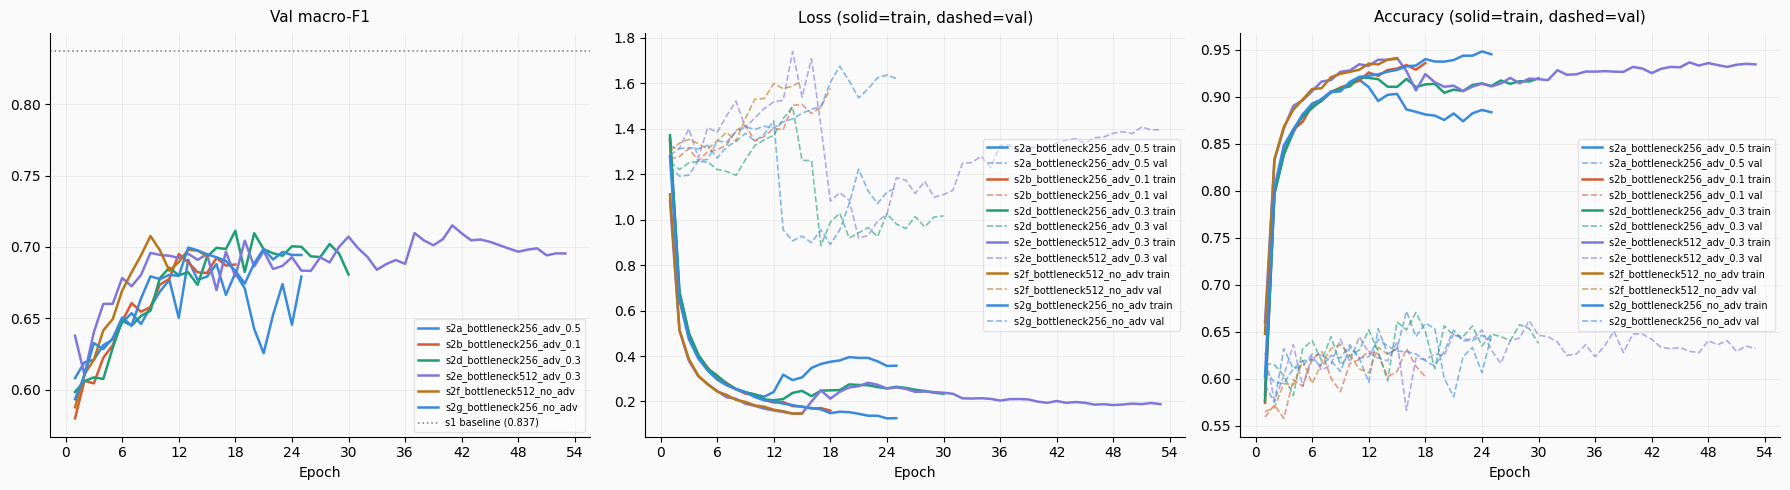

Saved to /data2/mromaniuc/cet-det/cet_perchv2/runs_stage2/stage2_learning_curves.png


In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import json

variant_files = sorted(RUNS_DIR.glob('*_config.json'))

COLORS = ['#378ADD', '#D85A30', '#1D9E75', '#7F77DD', '#BA7517']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#fafafa')
for ax in axes:
    ax.set_facecolor('#fafafa')
    ax.grid(True, alpha=0.25, linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

for i, vf in enumerate(variant_files):
    with open(vf) as f:
        cfg = json.load(f)
    h = cfg.get('history', {})
    name = cfg['variant']
    color = COLORS[i % len(COLORS)]
    epochs = range(1, len(h.get('val_macro_f1', [])) + 1)
    if not epochs:
        continue

    # F1
    axes[0].plot(epochs, h['val_macro_f1'],
                 color=color, linewidth=1.8, label=name)

    # Loss — solid train, dashed val, same color
    axes[1].plot(epochs, h['train_loss'],
                 color=color, linewidth=1.8, label=f'{name} train')
    axes[1].plot(epochs, h['val_loss'],
                 color=color, linewidth=1.2, linestyle='--', alpha=0.6,
                 label=f'{name} val')

    # Accuracy — solid train, dashed val
    axes[2].plot(epochs, h['train_acc'],
                 color=color, linewidth=1.8, label=f'{name} train')
    axes[2].plot(epochs, h['val_acc'],
                 color=color, linewidth=1.2, linestyle='--', alpha=0.6,
                 label=f'{name} val')

# Baseline on F1 only
axes[0].axhline(0.837, color='#888', linestyle=':', linewidth=1.2,
                label='s1 baseline (0.837)')

titles = ['Val macro-F1', 'Loss (solid=train, dashed=val)', 'Accuracy (solid=train, dashed=val)']
for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=11, fontweight='normal', pad=8)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.legend(fontsize=7, framealpha=0.5, loc='best')
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig(RUNS_DIR / 'stage2_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {RUNS_DIR / 'stage2_learning_curves.png'}")

## 8. Results summary

In [ ]:
print("\n" + "="*60)
print("STAGE 2 RESULTS SUMMARY")
print("="*60)
print(f"{'variant':<25} {'best_val_f1':>12} {'test_f1':>10} {'epoch':>6}")
print("-"*60)
for k, r in results.items():
    print(f"{r['variant']:<25} {r['best_val_macro_f1']:>12.4f} "
          f"{r['test_macro_f1']:>10.4f} {r['best_epoch']:>6}")

# Stage 1 baseline for comparison
print("-"*60)
print(f"{'s1_v10_cosine (frozen)':<25} {'0.837':>12} {'—':>10} {'35':>6}")

with open(RUNS_DIR / 'stage2_summary.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f"\nSummary saved to {RUNS_DIR / 'stage2_summary.json'}")

## 9. Extract projected embeddings for UMAP

Run after picking the best variant.
These are the embeddings to use for LODO and clustering analysis.

In [ ]:
# def extract_embeddings(model, X_all, batch_size=64):
#     """Extract projected embeddings for the full dataset."""
#     embeddings = []
#     n = len(X_all)
#     for i in range(0, n, batch_size):
#         batch = tf.constant(X_all[i:i+batch_size], dtype=tf.float32)
#         out   = model(batch, training=False)
#         embeddings.append(out['embedding'].numpy())
#         if i % 1000 == 0:
#             print(f"  {i}/{n}")
#     return np.concatenate(embeddings, axis=0)

# # ── Pick best variant (edit as needed) ───────────────────────────────────────
# # best_model = model_b   # e.g. s2b was best
# # emb_stage2 = extract_embeddings(best_model, X)
# # np.save(BASE / 'X_emb_stage2.npy', emb_stage2)
# # print(f"Saved embeddings: {emb_stage2.shape}")

## Notes
- `model(audio)['embedding']` = projected representation (use for UMAP/LODO)
- Raw Perch embedding still available via `FORWARD_FN(inputs=audio)['embedding']`
- For LODO: re-run perch_v2_cetacean_safe_lodo_run with X_emb_stage2.npy
- Augmentation (Stenella/Grampus) can be added before this stage